# Fine-tuning U-Net architecture — modèles 2,5D (séquentiels)
Notebook dédié au modèle qui exploite la dépendance entre coupes échographiques
d'un même poisson (voir `SliceSequenceUNetDataset`) :
- CSA-Net

In [1]:
import os
import numpy as np
import torch
import torch.optim as optim
import pickle
import time
import sys
import pandas as pd
import random

from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent))

from utils.models_config import (
    collate_fn_sequence, split_dataset, dataset_to_dict, metrics_by_class,
    save_validation_masks, save_validation_overlays,
)
from utils.post_traitement import keep_largest_components, fill_holes
from utils.stats_fct import plot_segmentation_comparison
from utils.fonctions_de_perte import BCE_Dice_ContourLoss_ignore
from utils.dataset_2_5D import SliceSequenceUNetDataset
from models.CSANet import CSANet


/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Gestion de la classe 'ignore' :
# True  -> les pixels ignore sont exclus de la loss et des métriques
# False -> les pixels ignore sont considérés comme du fond
IGNORE = True

# Seed global pour la reproductibilité des résultats
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


### Choix du modèle

In [ ]:
MODEL_NAME = "CSANet"

### Importation et traitement des données

In [4]:
# -------- 1. Importation des images et annotations --------
DATASET_NAME = "3classes"
DATASET_CONFIG = {
    "3classes": {
        "images": "../data/images/cavite",
        "annotations": "../data/labels/COCO/cavite/annotations.json",
    },
}
images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]

# ------- 2. Création des répertoires de sortie --------
masks_dir = f"masks/eval/{MODEL_NAME}/{DATASET_NAME}"
results_dir = f"results/eval/{MODEL_NAME}/{DATASET_NAME}"
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# ------- 3. Importation des métadonnées --------
df = pd.read_excel(
    "../utils/correspondance_echo_final.xlsx",
    dtype={"annee": str, "image_id": str, "new_name_file": str},
)

# -------- 4. Préparation du dataset --------
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(
    df, annotations_json, images_dir
)
gonade_id = class_ids.index(
    next((cid for cid, label in categories.items() if label == "Gonade"), class_ids[0])
) if ignore_category_id is not None else None
class_names = [categories[cid] for cid in class_ids]
ignore_mode = "pixels ignore exclus de la loss et des métriques" if IGNORE else "pixels ignore considérés comme fond"
print(f"Model : {MODEL_NAME}, Dataset : {DATASET_NAME}, classes={class_names}")
print(f"IGNORE={IGNORE} : {ignore_mode}")


Classes détectées (3) : {1: 'Cavite', 2: 'Gonade', 3: 'Intestin'}
Catégorie ignore détectée : 'ignore' (id=4)
Model : CSANet, Dataset : 3classes, classes=['Cavite', 'Gonade', 'Intestin']
IGNORE=True : pixels ignore exclus de la loss et des métriques


### Division du jeu de données

In [5]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test = split_dataset(all_samples)

Nombre total d'images valides : 169
Échantillons train/val        : 139
Échantillons de test          : 30


## CSA-Net — dépendance entre coupes échographiques

Les architectures précédentes traitent chaque image indépendamment. Or les images d'un même poisson forment une **séquence de coupes échographiques ordonnées** (voir `position` / `position_ratio` dans les métadonnées), qui s'apparente à un volume 3D pseudo-continu.

- Chaque coupe de la séquence est encodée indépendamment par l'encodeur ResNet34 (poids partagés entre les coupes).
- Les features du **bottleneck** (la représentation la plus profonde) sont mélangées le long de la dimension des coupes `T`, pour propager le contexte entre coupes voisines.
- Chaque coupe est ensuite décodée indépendamment par le décodeur U-Net habituel (skip connections non mélangées).

Entrée attendue : `(B, T, C, H, W)` — un batch de `B` séquences de `T` coupes RGB `(C=3, H=512, W=512)`.
Sortie : `(B, T, num_classes, H, W)` — un masque multi-classes par coupe.

### Dataset séquentiel par poisson (`SliceSequenceUNetDataset`)

Regroupe les coupes de `RoboflowUNetDataset` par poisson (`id_poisson`) et les trie par
position (`position_ratio`, repli sur `position`), pour produire des séquences
`(T, C, H, W)` / `(T, num_classes, H, W)` consommables par `CSANet` / `xLSTMUNet`.

- Le chargement par coupe (décodage COCO, crop, resize, normalisation) n'est pas
  dupliqué : ce dataset instancie en interne un `RoboflowUNetDataset(is_train=False)`.
- Pas de padding : la longueur `T` varie selon le poisson (1 à 7 coupes dans les
  données actuelles) → chaque batch = un seul poisson (`batch_size=1`, via
  `collate_fn_sequence`).
- Augmentation appliquée au niveau de la séquence entière (`data_augmentation_sequence`),
  pas coupe par coupe, pour ne pas casser la correspondance spatiale entre coupes.

### Hyperparamètres du modèle et initialisation

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- Hyperparamètres ----
EPOCHS = 150
nb_channels = 3
learning_rate = 1e-3
IMAGE_SIZE = (512, 512)

# ---- Fonction de perte ----
loss_fn = BCE_Dice_ContourLoss_ignore(
    bce_weight=0.5, dice_weight=0.5, contour_weight=0, ignore_index=-100
)

# ---- Early stopping et scheduler ----
early_stopping_patience = 10
early_stopping_min_delta = 1e-3
lr_patience = 3

# ---- Cross-validation ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

def get_cv_splits():
    return kf.split(cv_samples, cv_categories, groups_train)

def build_model():
    return CSANet(
        num_classes=num_classes,
        in_channels=nb_channels,
        encoder_weights="imagenet",
    )

def build_dataset(samples, is_train=False):
    return SliceSequenceUNetDataset(
        samples=samples,
        image_dir=images_dir,
        df=df,
        image_size=IMAGE_SIZE,
        num_classes=num_classes,
        class_ids=class_ids,
        is_train=is_train,
        ignore_category_id=ignore_category_id,
        ignore_target_class_idx=gonade_id if IGNORE else None,
    )

fold_results = {}
fold_histories = {}


Utilisation de l'appareil: cuda


### Images selectionnées par batch

In [18]:
# Chaque batch du dataset séquentiel contient un poisson complet :
# (1, T, C, H, W), avec T variable selon le nombre de coupes.
for fold, (_, val_idx) in enumerate(get_cv_splits(), start=1):
    val_names = [cv_samples[i]["image_info"]["file_name"] for i in val_idx]
    print(f"Fold {fold}/{k_folds} — {len(val_names)} coupes de validation")
    print(val_names)


Fold 1/5 — 29 coupes de validation
['0004647_11.15.45_356859_2019.jpg', '0004648_11.15.58_356859_2019.jpg', '0004649_11.16.08_356859_2019.jpg', '0004664_11.58.29_356918_2019.jpg', '0004665_11.58.41_356918_2019.jpg', '0004666_11.58.51_356918_2019.jpg', '0004724_11.08.16_357291_2019.jpg', '0004725_11.08.26_357291_2019.jpg', '0004726_11.08.34_357291_2019.jpg', '0004727_11.08.43_357291_2019.jpg', '0004734_11.20.45_357305_2019.jpg', '0004735_11.20.53_357305_2019.jpg', '0004736_11.21.16_357305_2019.jpg', '0004872_14.42.39_362728_2020.jpg', '0004873_14.42.49_362728_2020.jpg', '0004874_14.42.59_362728_2020.jpg', '0004875_14.43.14_362728_2020.jpg', '0005022_17.09.00_363529_2020.jpg', '0005023_17.09.18_363529_2020.jpg', '0005928_11.37.06_405826_2022.jpg', '0005929_11.37.16_405826_2022.jpg', '0005930_11.37.22_405826_2022.jpg', '0005931_11.37.26_405826_2022.jpg', '0007100_09.42.31_427181_2024.jpg', '0007101_09.42.42_427181_2024.jpg', '0007102_09.42.49_427181_2024.jpg', '0007103_09.43.00_427181_202

### Entrainement et validation du modèle

In [19]:
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time()

    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]
    train_dataset = build_dataset(train_samples, is_train=True)
    val_dataset = build_dataset(val_samples)

    loader_g = torch.Generator().manual_seed(SEED + fold)
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True,
                              collate_fn=collate_fn_sequence, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                            collate_fn=collate_fn_sequence)

    # Le dataset trie les coupes dans chaque poisson. Les métadonnées sont donc
    # retrouvées par chemin, plutôt que par leur position dans val_samples.
    val_meta_by_path = {
        sample["image_path"]: (
            sample["category"], int(sample["position"]),
            float(sample["position_ratio"]),
            float(df.loc[df["image_id"] == sample["image_info"]["file_name"].split("_")[0], "echelle"].iloc[0]),
        )
        for sample in val_samples
    }

    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)
    model = build_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=lr_patience
    )

    history = {"train_loss": [], "val_loss": [], "val_iou": [],
               "val_iou_all": [], "best_epochs": []}
    best_result = {"iou_by_class": {}, "dice_by_class": {},
                   "precision_by_class": {}, "recall_by_class": {},
                   "diff_surface": {}, "category": [], "ops": [],
                   "ops_ratio": [], "name": []}
    best_val_loss = float("inf")
    best_val_masks, best_val_images = [], []
    idx_best_epoch = -1
    early_stopping_counter = 0

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        train_dataset.epoch = epoch
        val_dataset.epoch = epoch

        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True).squeeze(0)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images).squeeze(0)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * masks.size(0)
            running_count += masks.size(0)
        avg_train_loss = running_loss / running_count if running_count else 0.0

        model.eval()
        val_loss = 0.0
        val_count = 0
        epoch_intersection = torch.zeros(num_classes, device=device)
        epoch_union = torch.zeros(num_classes, device=device)
        epoch_metrics = {key: [] for key in ("iou", "dice", "precision", "recall", "diff_surface")}
        epoch_names, epoch_categories, epoch_ops, epoch_ops_ratio = [], [], [], []
        epoch_val_masks, epoch_val_images = [], []

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True).squeeze(0)
                outputs = model(images).squeeze(0)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item() * masks.size(0)
                val_count += masks.size(0)

                valid_mask = masks != -100
                true = (masks > 0.5) & valid_mask
                preds = (torch.sigmoid(outputs) > 0.5) & valid_mask
                if preds.shape[1] > 1:
                    preds = fill_holes(keep_largest_components(preds))
                preds &= valid_mask

                image_paths = batch["image_path"][0]
                file_names = [Path(image_path).name for image_path in image_paths]
                scales = torch.tensor(
                    [val_meta_by_path[path][3] for path in image_paths],
                    device=device, dtype=torch.float32,
                ).view(-1, 1)
                metrics = metrics_by_class(true, preds, scales, DATASET_NAME)
                intersection, union, iou, dice, precision, recall, diff_surface = metrics
                epoch_intersection += intersection.sum(dim=0)
                epoch_union += union.sum(dim=0)
                for key, value in zip(epoch_metrics, (iou, dice, precision, recall, diff_surface)):
                    epoch_metrics[key].append(value)

                epoch_names.extend(file_names)
                for image_path in image_paths:
                    category, op, op_ratio, _ = val_meta_by_path[image_path]
                    epoch_categories.append(category)
                    epoch_ops.append(op)
                    epoch_ops_ratio.append(op_ratio)
                epoch_val_masks.extend(
                    (name, target.cpu().clone(), pred.cpu().clone())
                    for name, target, pred in zip(file_names, true, preds)
                )
                epoch_val_images.extend(
                    (name, image.cpu().clone(), pred.cpu().clone())
                    for name, image, pred in zip(file_names, images.squeeze(0), preds)
                )

        avg_val_loss = val_loss / val_count if val_count else 0.0
        mean_val_iou = (epoch_intersection / (epoch_union + 1e-6)).mean().item()
        mean_val_iou_all = (epoch_intersection.sum() / (epoch_union.sum() + 1e-6)).item()
        scheduler.step(avg_val_loss)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_iou"].append(mean_val_iou)
        history["val_iou_all"].append(mean_val_iou_all)

        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            idx_best_epoch = epoch
            early_stopping_counter = 0
            os.makedirs("saves", exist_ok=True)
            torch.save(model.state_dict(), f"saves/unet_finetuned_fold_{fold + 1}_{MODEL_NAME}_{DATASET_NAME}.pth")
            best_val_masks = [(name, target.clone(), pred.clone()) for name, target, pred in epoch_val_masks]
            best_val_images = [(name, image.clone(), pred.clone()) for name, image, pred in epoch_val_images]
            best_result.update({
                key + "_by_class": {label: [row[index] for row in torch.cat(values).cpu().tolist()]
                                     for index, label in enumerate(class_names)}
                for key, values in epoch_metrics.items() if key != "diff_surface"
            })
            best_result["diff_surface"] = {
                label: [row[index] for row in torch.cat(epoch_metrics["diff_surface"]).cpu().tolist()]
                for index, label in enumerate(class_names)
            }
            best_result.update({"category": epoch_categories, "ops": epoch_ops,
                                "ops_ratio": epoch_ops_ratio, "name": epoch_names})
            history["best_epochs"] = [idx_best_epoch]
        else:
            early_stopping_counter += 1

        elapsed = time.time() - epoch_start
        print(f"Epoch {epoch}/{EPOCHS} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {elapsed:.1f}s, lr: {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")
        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration.")
            break

    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    save_validation_masks(masks_dir, best_val_masks)
    save_validation_overlays(results_dir, best_val_images, dataset_name=DATASET_NAME, class_names=class_names)
    fold_total_time = time.time() - fold_start_time
    best_result["time"] = fold_total_time
    fold_results[f"fold_{fold + 1}"] = best_result
    fold_histories[f"fold_{fold + 1}"] = history


--- DEBUT DU FOLD 1/5 ---
Epoch 1/150 — train_loss: 0.5620, val_loss: 0.4563, val_iou: 0.5333, time: 5.8s, lr: 1.00e-03, early_stopping: 0/10
Epoch 2/150 — train_loss: 0.3714, val_loss: 0.5576, val_iou: 0.0717, time: 5.3s, lr: 1.00e-03, early_stopping: 1/10
Epoch 3/150 — train_loss: 0.3200, val_loss: 0.3743, val_iou: 0.4605, time: 5.8s, lr: 1.00e-03, early_stopping: 0/10
Epoch 4/150 — train_loss: 0.2714, val_loss: 0.3129, val_iou: 0.4851, time: 5.8s, lr: 1.00e-03, early_stopping: 0/10
Epoch 5/150 — train_loss: 0.2556, val_loss: 0.2629, val_iou: 0.6496, time: 5.7s, lr: 1.00e-03, early_stopping: 0/10
Epoch 6/150 — train_loss: 0.2390, val_loss: 0.2789, val_iou: 0.5375, time: 5.3s, lr: 1.00e-03, early_stopping: 1/10
Epoch 7/150 — train_loss: 0.2504, val_loss: 0.3836, val_iou: 0.4125, time: 5.2s, lr: 1.00e-03, early_stopping: 2/10
Epoch 8/150 — train_loss: 0.2282, val_loss: 0.3140, val_iou: 0.6251, time: 5.3s, lr: 1.00e-03, early_stopping: 3/10
Epoch 9/150 — train_loss: 0.2426, val_loss: 0.

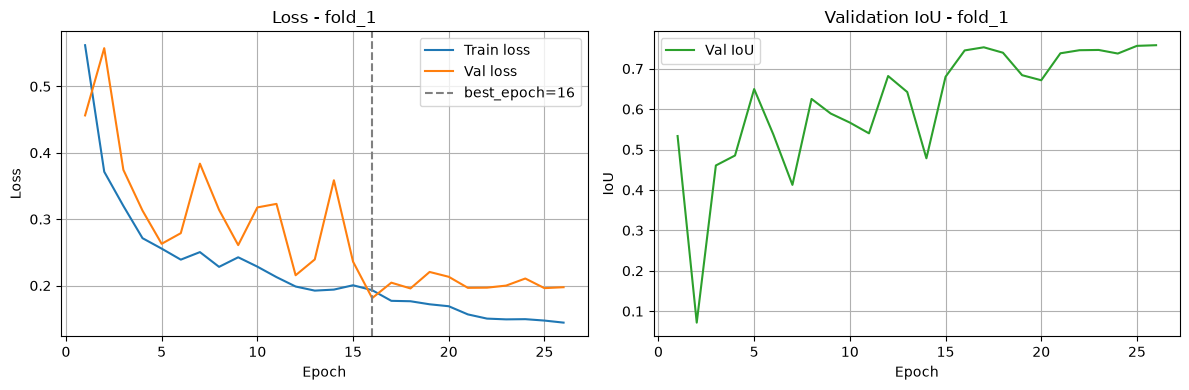

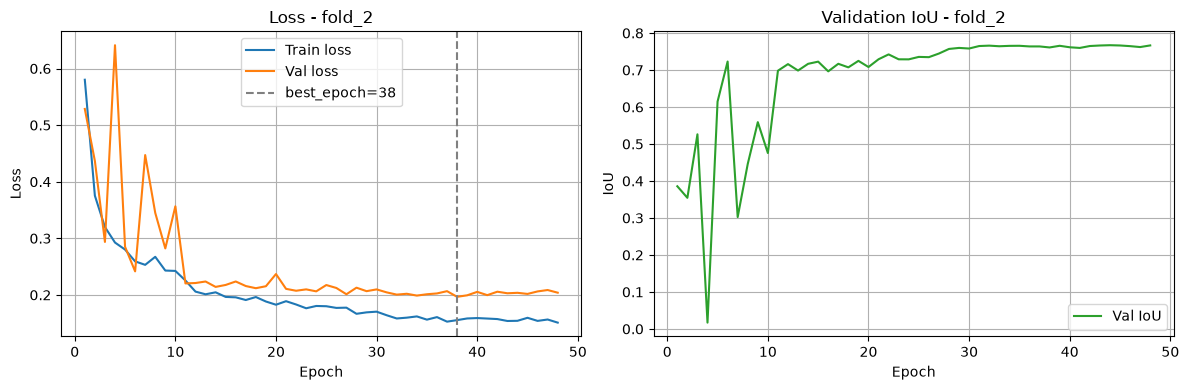

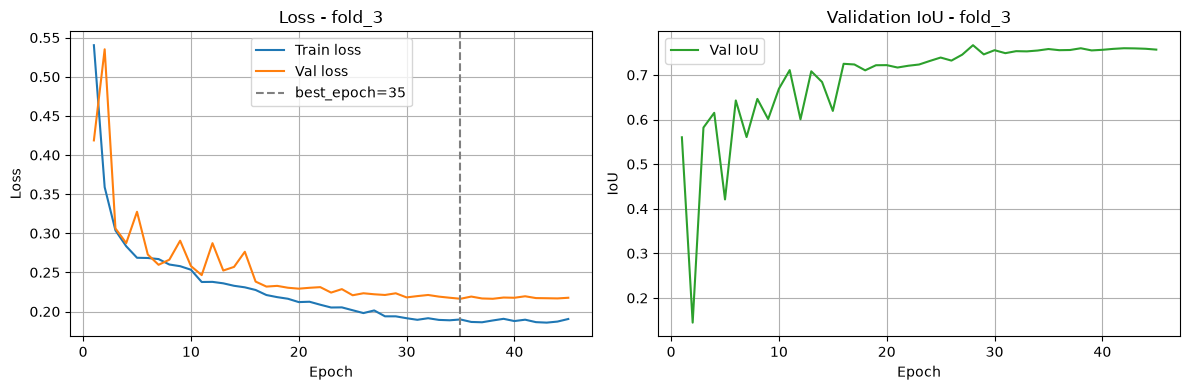

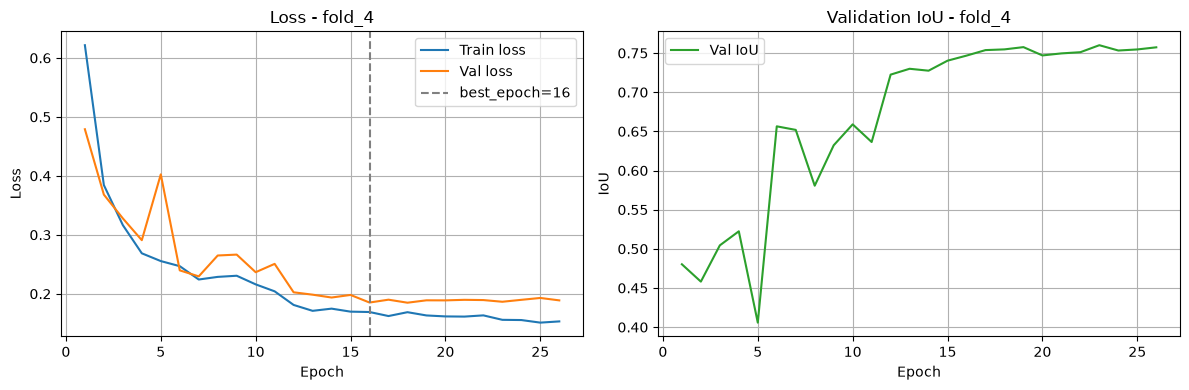

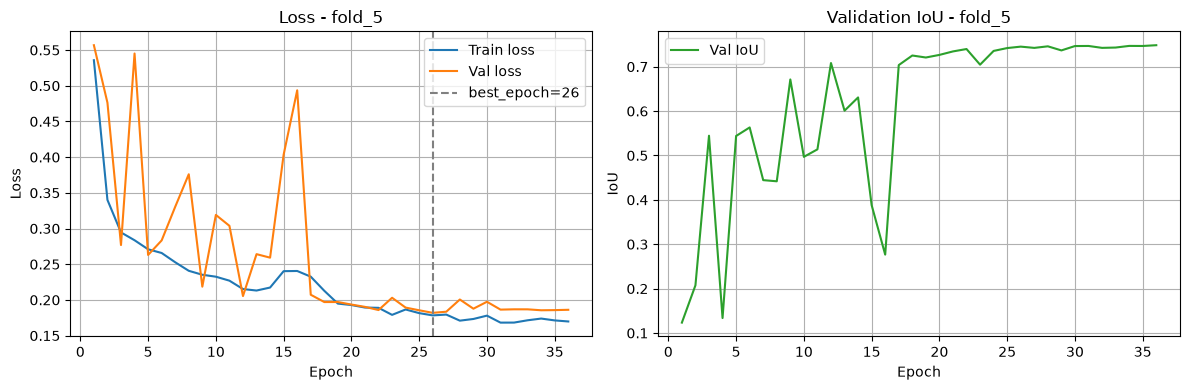

In [20]:
for fold_name, history in fold_histories.items():
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    best_epoch = history["best_epochs"][0] if history["best_epochs"] else 0
    epochs = range(1, len(history["train_loss"]) + 1)
    axs[0].plot(epochs, history["train_loss"], label="Train loss")
    axs[0].plot(epochs, history["val_loss"], label="Val loss")
    if best_epoch:
        axs[0].axvline(best_epoch, color="gray", linestyle="--", label=f"best_epoch={best_epoch}")
    axs[0].set(title=f"Loss - {fold_name}", xlabel="Epoch", ylabel="Loss")
    axs[0].legend(); axs[0].grid(True)
    axs[1].plot(epochs, history["val_iou_all"], label="Val IoU", color="tab:green")
    axs[1].set(title=f"Validation IoU - {fold_name}", xlabel="Epoch", ylabel="IoU")
    axs[1].legend(); axs[1].grid(True)
    plt.tight_layout(); plt.show()


### Sauvegarde des résultats

In [24]:
# Sauvegarde des métriques du meilleur epoch de chaque fold.
with open(f"results_{MODEL_NAME}_{DATASET_NAME}.pkl", "wb") as results_file:
    pickle.dump(fold_results, results_file)


## Résultats validation

Choisir une coupe de validation par son nom de fichier, ou par fold et index. La séquence
complète de son poisson est reconstruite afin de fournir à CSA-Net le contexte 2,5D attendu.


In [22]:
# ------------ 1. Choix de la coupe -------------
VIS_FILENAME = "0007102_09.42.49_427181_2024.jpg" # Exemple : '0007102_09.42.49_427181_2024.jpg'
VIS_FOLD = 1
VIS_INDEX = 0  # Index parmi les coupes de validation du fold


,dice,iou,precision,recall,diff_surface (cm²)
classe,,,,,
Cavite,0.9149,0.8432,0.9661,0.8689,0.2588
Gonade,0.8223,0.6982,0.9888,0.7038,0.4376
Intestin,0.6295,0.4594,0.7238,0.5570,0.1119
Global,0.8567,0.7494,0.9486,0.7811,0.8084


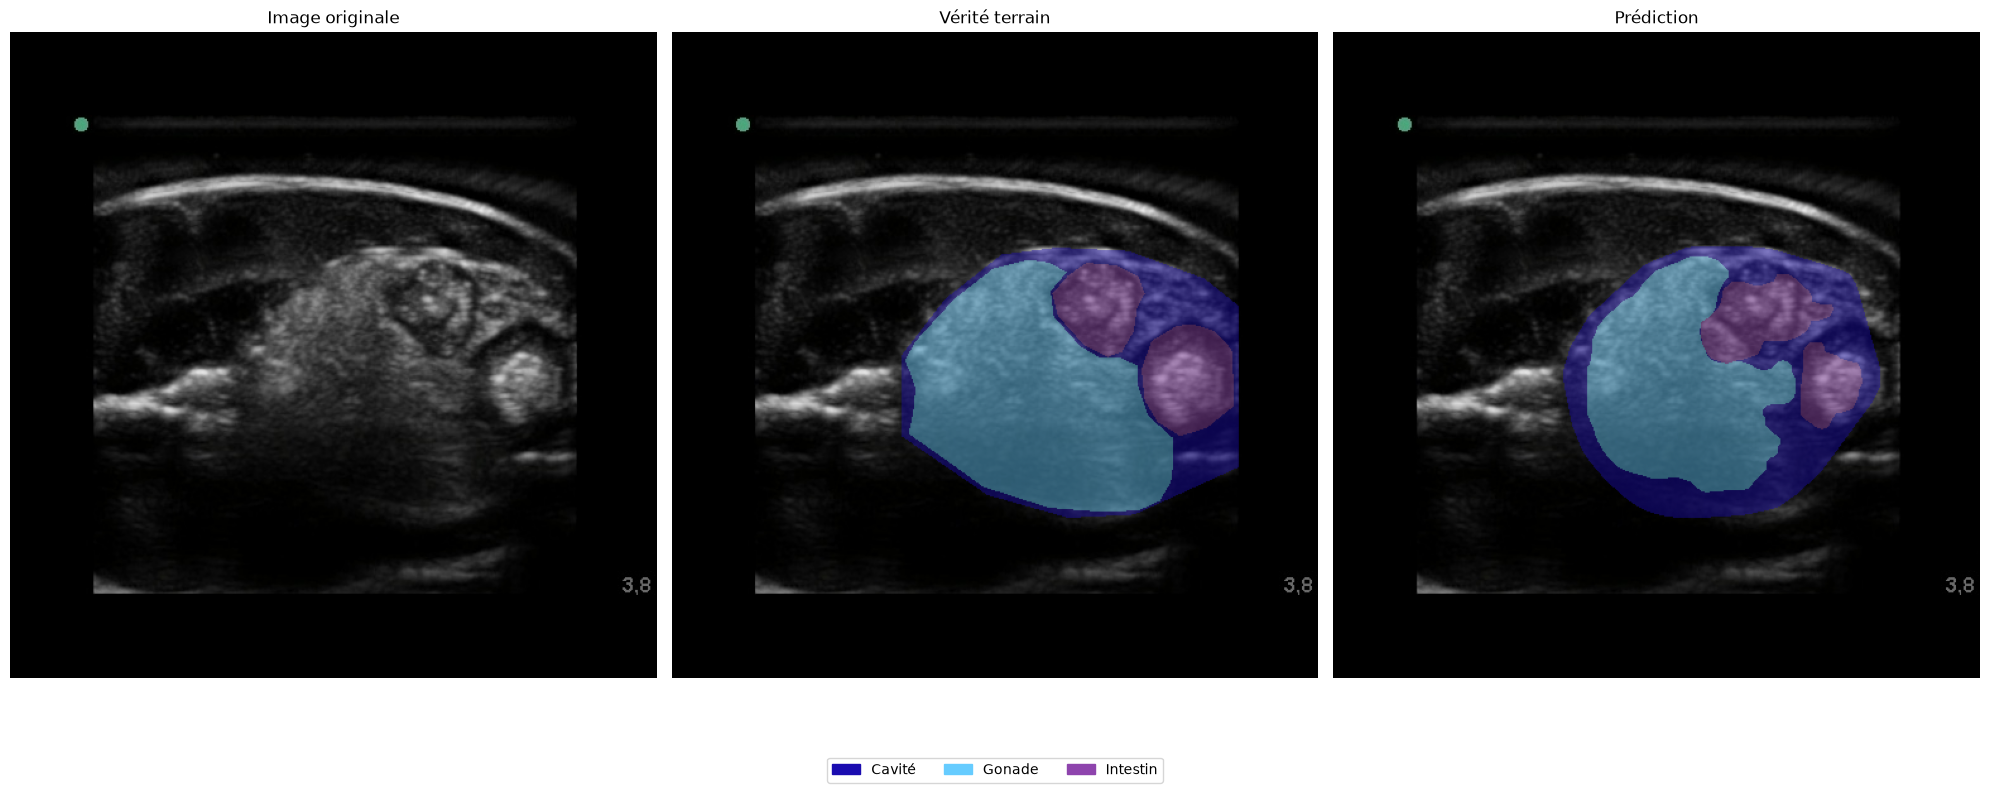

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>,
        <Axes: title={'center': 'Vérité terrain'}>,
        <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [23]:
# ------------ 2. Reconstruction de la séquence et inférence -------------
cv_splits = list(get_cv_splits())
if VIS_FILENAME:
    requested_name = Path(VIS_FILENAME).name
    matches = []
    for fold_index, (_, indices) in enumerate(cv_splits, start=1):
        for local_index, sample_index in enumerate(indices):
            if Path(cv_samples[int(sample_index)]["image_info"]["file_name"]).name == requested_name:
                matches.append((fold_index, local_index, int(sample_index)))
    if len(matches) != 1:
        raise ValueError(f"Le fichier {requested_name} doit correspondre à une seule coupe de validation; correspondances: {matches}")
    VIS_FOLD, VIS_INDEX, sample_index = matches[0]
else:
    if not 1 <= VIS_FOLD <= len(cv_splits):
        raise ValueError(f"VIS_FOLD doit être compris entre 1 et {len(cv_splits)}.")
    _, indices = cv_splits[VIS_FOLD - 1]
    if not 0 <= VIS_INDEX < len(indices):
        raise IndexError(f"VIS_INDEX doit être compris entre 0 et {len(indices) - 1}.")
    sample_index = int(indices[VIS_INDEX])

sample = cv_samples[sample_index]
target_path = sample["image_path"]
_, val_indices = cv_splits[VIS_FOLD - 1]
val_samples = [cv_samples[i] for i in val_indices]
dataset_vis = build_dataset(val_samples)

sequence_index = next(
    index for index in range(len(dataset_vis))
    if target_path in dataset_vis[index]["image_path"]
)
sequence = dataset_vis[sequence_index]
slice_index = sequence["image_path"].index(target_path)
images = sequence["image"].unsqueeze(0).to(device)
masks = sequence["mask"].to(device)

checkpoint_path = Path(f"saves/unet_finetuned_fold_{VIS_FOLD}_{MODEL_NAME}_{DATASET_NAME}.pth")
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")
model_eval = build_model().to(device)
model_eval.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_eval.eval()
with torch.inference_mode():
    logits = model_eval(images).squeeze(0)

valid_mask = masks != -100
true = (masks > 0.5) & valid_mask
preds = (torch.sigmoid(logits) > 0.5) & valid_mask
if preds.shape[1] > 1:
    preds = fill_holes(keep_largest_components(preds))
preds &= valid_mask

file_name = Path(target_path).name
scale = float(df.loc[df["image_id"] == file_name.split("_")[0], "echelle"].iloc[0])
metrics = metrics_by_class(true[slice_index:slice_index + 1], preds[slice_index:slice_index + 1],
                           torch.tensor([[scale]], device=device), DATASET_NAME)
intersection, union, iou, dice, precision, recall, diff_surface = metrics
rows = [{"classe": label, "dice": dice[0, index].item(), "iou": iou[0, index].item(),
         "precision": precision[0, index].item(), "recall": recall[0, index].item(),
         "diff_surface (cm²)": diff_surface[0, index].item()}
        for index, label in enumerate(class_names)]
true_global = true[slice_index].sum()
pred_global = preds[slice_index].sum()
intersection_global = intersection.sum()
union_global = union.sum()
rows.append({"classe": "Global",
             "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
             "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
             "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
             "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
             "diff_surface (cm²)": diff_surface.sum().item()})
display(pd.DataFrame(rows).set_index("classe").style.format(precision=4))
plot_segmentation_comparison(sequence["image"][slice_index], true[slice_index].cpu(), preds[slice_index].cpu(), alpha=0.45)
